# Protein Fitness Landscape Gradient-Aware Manifold Fitting

Run the same proof-of-concept pipeline as the S-curve notebook on the P450 fitness landscape data from Ding, Zou, and Brooks (Nature Communications, 2019).

The paper uses a VAE/autoencoder latent space. The prepared files here include P450 genotype features and measured `T50`, but not the actual latent `z` coordinates. This notebook will use `p450_numeric_latent_z2.npy` or `p450_numeric_latent_z30.npy` if either file is added later; otherwise it falls back to the 24D one-hot encoding of the eight P450 fragment choices. The plots below use 2D PCA and Flowmap UMAP visualizations of whichever position source is loaded.


In [6]:
from pathlib import Path
import os
import sys

# Flowmap/UMAP uses numba caching; keep caches in writable local temp dirs.
os.environ.setdefault("NUMBA_CACHE_DIR", "/private/tmp/numba_cache")
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mplconfig")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from flowmap.flowmap_embedding import VectorFieldEmbedder
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

repo_root = Path.cwd()
if not (repo_root / "scripts").exists():
    repo_root = repo_root.parent.parent
sys.path.insert(0, str(repo_root))

from scripts.manfit import manfit
from scripts.velocity_manifold_fitter import VelocityManifoldFitter

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
})


## Observed Data

For the real protein landscape we do not have a clean ground-truth gradient field. The only inputs to the fitting pipeline are an observed position representation and the measured scalar potential `T50`. The position source is selected in the next cell and reported explicitly.


In [7]:
data_dir = repo_root / "data" / "protein_latent_paper"

fitness = pd.read_csv(data_dir / "p450_fitness.csv")
sequence_ids = np.load(data_dir / "p450_numeric_sequence_ids.npy")
genotypes = np.load(data_dir / "p450_numeric_genotypes.npy")
onehot = np.load(data_dir / "p450_numeric_onehot.npy").astype(float)
t50 = np.load(data_dir / "p450_numeric_t50.npy").astype(float)
split = np.load(data_dir / "p450_numeric_split.npy")

# Prefer autoencoder latent coordinates if they are added later. The currently prepared
# supplementary files do not include these coordinates, so the fallback is genotype one-hot.
latent_candidates = [
    data_dir / "p450_numeric_latent_z2.npy",
    data_dir / "p450_numeric_latent_z30.npy",
]
latent_path = next((path for path in latent_candidates if path.exists()), None)

if latent_path is not None:
    raw_position = np.load(latent_path).astype(float)
    position_source = latent_path.name
else:
    raw_position = onehot
    position_source = "p450_numeric_onehot.npy"

# Standardize coordinates and scalar so the neighborhood regression is numerically tame.
position = StandardScaler(with_mean=True, with_std=True).fit_transform(raw_position)
scalar = (t50 - t50.mean()) / t50.std()

observed_data = {
    "position": position,
    "scalar": scalar,
    "t50": t50,
    "sequence_id": sequence_ids,
    "genotype": genotypes,
    "split": split,
    "position_source": position_source,
}

{
    "n_samples": observed_data["position"].shape[0],
    "position_dim": observed_data["position"].shape[1],
    "position_source": observed_data["position_source"],
    "t50_min": float(t50.min()),
    "t50_max": float(t50.max()),
    "t50_mean": float(t50.mean()),
}


{'n_samples': 239,
 'position_dim': 24,
 'position_source': 'p450_numeric_onehot.npy',
 't50_min': 39.20000076293945,
 't50_max': 64.4000015258789,
 't50_mean': 52.08033482699215}

## Local Gradient Estimator

Estimate a local gradient field from the observed genotype-feature positions and observed T50 values using the same ridge-regression neighborhood estimator as in the S-curve notebook.

In [8]:
def estimate_gradient_from_neighbors(X, values, n_neighbors=42, ridge=5e-2):
    """Estimate an ambient gradient field from positions and scalar values."""
    X = np.asarray(X, dtype=float)
    values = np.asarray(values, dtype=float)
    if X.ndim != 2:
        raise ValueError("X must be a 2D array")
    if values.shape[0] != X.shape[0]:
        raise ValueError("values must have one entry per row of X")

    n_neighbors = min(int(n_neighbors), X.shape[0] - 1)
    nbrs = NearestNeighbors(n_neighbors=n_neighbors + 1).fit(X)
    _, indices = nbrs.kneighbors(X)
    gradients = np.zeros_like(X)
    eye = np.eye(X.shape[1])

    for i, neigh in enumerate(indices[:, 1:]):
        dX = X[neigh] - X[i]
        df = values[neigh] - values[i]
        gradients[i] = np.linalg.solve(dX.T @ dX + ridge * eye, dX.T @ df)

    return gradients

estimated_gradient = estimate_gradient_from_neighbors(
    observed_data["position"],
    observed_data["scalar"],
    n_neighbors=24,
    ridge=1e-2,
)


## Fit Manifolds

Position-only fitting consumes only `observed_data["position"]`. Position + gradient fitting consumes `observed_data["position"]` and the gradient estimated from `observed_data`. There is no ground-truth information in either fit.

In [9]:
def fit_position_only(X, scalar, knn=24, gradient_n_neighbors=42, gradient_ridge=5e-2):
    """Run position-only MANFIT from scripts/manfit.py, then estimate gradients."""
    X_fit = manfit(
        X,
        knn=knn,
        transform="value2trans",
        use_matlab_mink=True,
    )
    V_fit = estimate_gradient_from_neighbors(
        X_fit,
        scalar,
        n_neighbors=gradient_n_neighbors,
        ridge=gradient_ridge,
    )
    return {
        "position": X_fit,
        "gradient": V_fit,
    }


def fit_position_plus_gradient(
    X,
    V,
    k=15,
    T=8,
    eta_g=0.35,
    theta=0.2,
    kappa=2.0,
    adaptive_variance_threshold=0.85,
    adaptive_d_min=2,
    random_state=0,
):
    """Run gradient-aware manifold fitting from positions and gradient vectors."""
    fitter = VelocityManifoldFitter(
        X,
        V,
        d_mode="adaptive",
        adaptive_variance_threshold=adaptive_variance_threshold,
        adaptive_d_min=adaptive_d_min,
        k=k,
        T=T,
        eta_g=eta_g,
        theta=theta,
        kappa=kappa,
        bandwidth_mode="variable",
        use_PCA=False,
        random_state=random_state,
    )
    result = fitter.fit(update_mode="normal_only", return_dict=True)
    return {
        "position": result["X"],
        "gradient": result["V"],
        "raw_result": result,
    }

position_fit = fit_position_only(
    observed_data["position"],
    observed_data["scalar"],
    knn=24,
    gradient_n_neighbors=24,
    gradient_ridge=1e-2,
)

gradient_fit = fit_position_plus_gradient(
    observed_data["position"],
    estimated_gradient,
    k=20,
    T=8,
    eta_g=0.35,
    theta=0.2,
    kappa=2.0,
)


## Visual Comparison

Rows mirror the S-curve notebook: observed data, position-only manifold fitting, and position + gradient manifold fitting. The left column shows measured `T50`; the right column shows the local or fitted gradient field. We show two 2D views: a PCA projection with arrows and a Flowmap UMAP embedding with arrows. Each row uses its own axis limits so the position-only MANFIT cloud is visible despite its smaller scale.


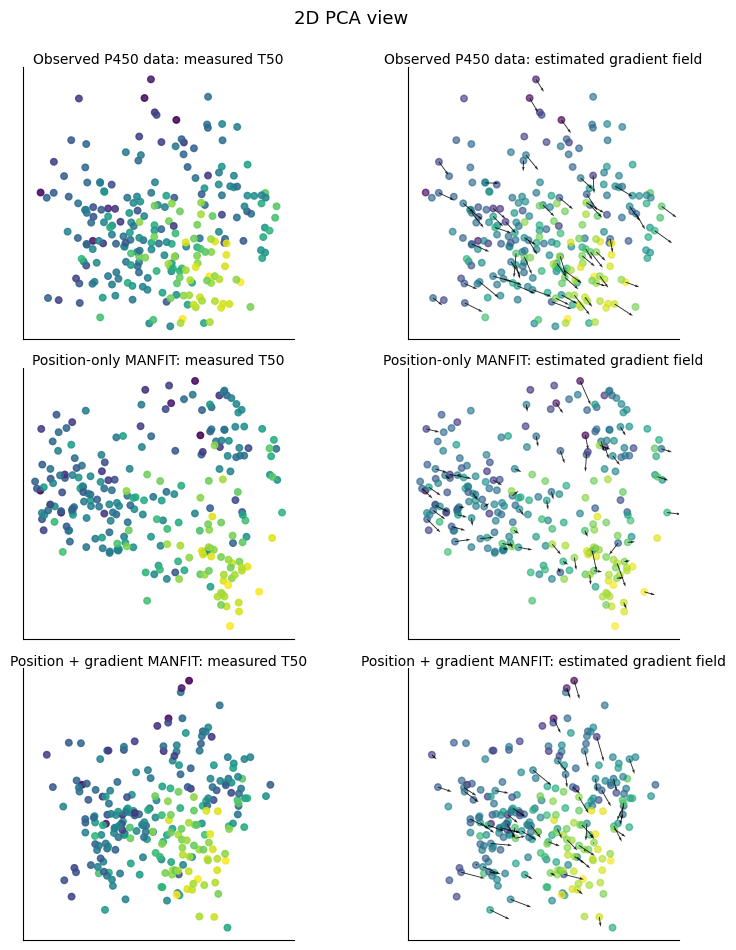

[Spline] Fitting manifold spline on 239 cells …
[Spline] Using all 239 points as control points.
[Spline] Mapping vector field …
[Spline] Fitting velocity spline …
[Spline] Using all 239 points as control points.
[FlowMap] Done.
[Spline] Fitting manifold spline on 239 cells …
[Spline] Using all 239 points as control points.
[Spline] Mapping vector field …
[Spline] Fitting velocity spline …
[Spline] Using all 239 points as control points.
[FlowMap] Done.
[Spline] Fitting manifold spline on 239 cells …
[Spline] Using all 239 points as control points.
[Spline] Mapping vector field …
[Spline] Fitting velocity spline …
[Spline] Using all 239 points as control points.
[FlowMap] Done.


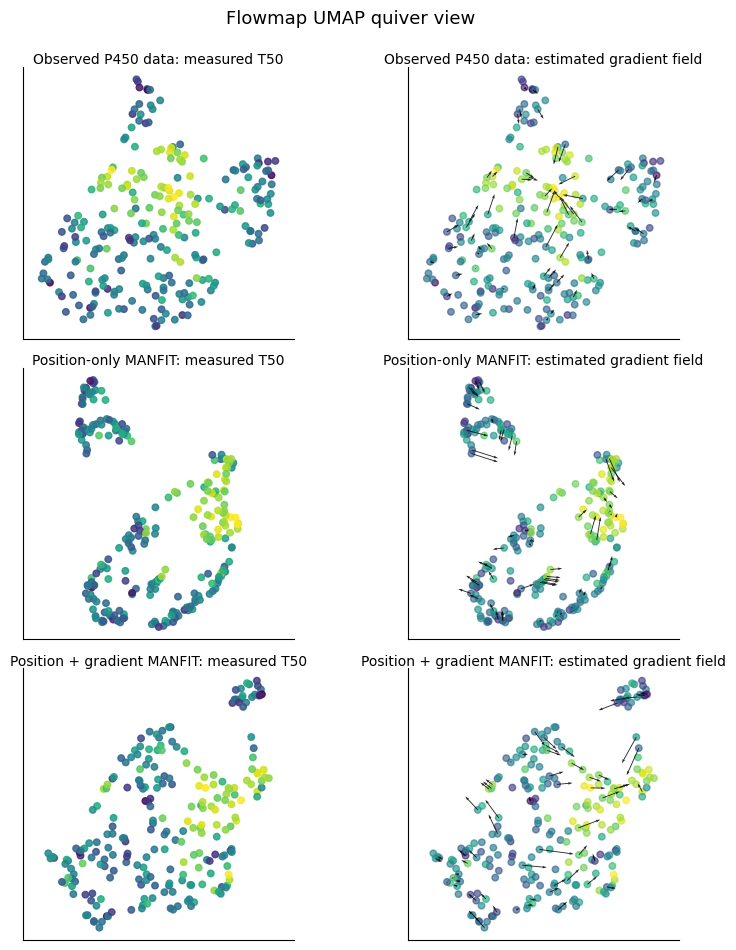

In [11]:
def clean_2d_axis(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_aspect("equal", adjustable="box")


def set_pair_2d_limits(ax_left, ax_right, Z):
    mins = Z.min(axis=0)
    maxs = Z.max(axis=0)
    centers = (mins + maxs) / 2
    radius = np.max(maxs - mins) / 2
    radius = max(radius, np.finfo(float).eps)
    pad = 0.10 * radius
    for ax in (ax_left, ax_right):
        ax.set_xlim(centers[0] - radius - pad, centers[0] + radius + pad)
        ax.set_ylim(centers[1] - radius - pad, centers[1] + radius + pad)


def draw_scalar_panel_2d(ax, Z, color, title):
    ax.scatter(Z[:, 0], Z[:, 1], c=color, cmap="viridis", s=22, alpha=0.86)
    ax.set_title(title, fontsize=10, pad=2)
    clean_2d_axis(ax)


def scale_vectors_for_display(Z, V, arrow_frac=0.055):
    span = max(np.ptp(Z[:, 0]), np.ptp(Z[:, 1]), np.finfo(float).eps)
    norms = np.linalg.norm(V, axis=1)
    nonzero = norms[norms > np.finfo(float).eps]
    if nonzero.size == 0:
        return V
    robust_norm = np.percentile(nonzero, 95)
    return V * (arrow_frac * span / robust_norm)


def draw_quiver_panel_2d(ax, Z, V, color, title, arrow_frac=0.055):
    step = max(1, Z.shape[0] // 55)
    V_plot = scale_vectors_for_display(Z, V, arrow_frac=arrow_frac)
    ax.scatter(Z[:, 0], Z[:, 1], c=color, cmap="viridis", s=22, alpha=0.65)
    ax.quiver(
        Z[::step, 0], Z[::step, 1],
        V_plot[::step, 0], V_plot[::step, 1],
        angles="xy", scale_units="xy", scale=0.5,
        color="black", width=0.0032, alpha=0.85,
    )
    ax.set_title(title, fontsize=10, pad=2)
    clean_2d_axis(ax)


raw_rows = [
    ("Observed P450 data", observed_data["position"], estimated_gradient),
    ("Position-only MANFIT", position_fit["position"], position_fit["gradient"]),
    ("Position + gradient MANFIT", gradient_fit["position"], gradient_fit["gradient"]),
]


def make_pca_view(rows_raw):
    pca = PCA(n_components=2, random_state=0).fit(observed_data["position"])
    return [
        (label, pca.transform(X), V @ pca.components_.T)
        for label, X, V in rows_raw
    ]


def make_flowmap_umap_view(rows_raw):
    rows = []
    for label, X, V in rows_raw:
        embedder = VectorFieldEmbedder(
            X,
            V,
            method="umap",
            embedding_dim=2,
            dist_method="euclidean",
            embed_kwargs={"n_neighbors": 20, "min_dist": 0.1},
            use_PCA=False,
            n_control_points=min(4000, X.shape[0]),
        )
        embedder.fit_embedding(seed=0)
        rows.append((label, embedder.X_emb, embedder.V_emb))
    return rows


def plot_2d_view(rows, title, arrow_frac=0.055):
    fig, axs = plt.subplots(3, 2, figsize=(8.8, 9.5), constrained_layout=False)
    for row_idx, (row_title, Z, V) in enumerate(rows):
        draw_scalar_panel_2d(
            axs[row_idx, 0],
            Z,
            observed_data["t50"],
            f"{row_title}: measured T50",
        )
        draw_quiver_panel_2d(
            axs[row_idx, 1],
            Z,
            V,
            observed_data["t50"],
            f"{row_title}: estimated gradient field",
            arrow_frac=arrow_frac,
        )
        set_pair_2d_limits(axs[row_idx, 0], axs[row_idx, 1], Z)
    fig.suptitle(title, fontsize=13, y=0.995)
    fig.tight_layout()
    return fig


pca_rows = make_pca_view(raw_rows)
fig_pca = plot_2d_view(pca_rows, "2D PCA view", arrow_frac=0.045)
plt.show()

umap_rows = make_flowmap_umap_view(raw_rows)
fig_umap = plot_2d_view(umap_rows, "Flowmap UMAP quiver view", arrow_frac=0.05)
plt.show()
